In [1]:
%load_ext autoreload
%autoreload 2

import warnings
import matplotlib.pyplot as plt
import numpy as np
import glob
import xarray as xr
import gsw
# import regionate
import cartopy.crs as ccrs
# import CM4Xutils #needed to run pip install nc-time-axis
import sys
sys.path.insert(0, '/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/src')
from src import *
import cartopy.feature as cfeature
import warnings
# from numpy import RankWarning
import cmocean as cm
warnings.filterwarnings('ignore')
import xesmf as xe
from meridional_streamfunction import * 

In [2]:
from dask_jobqueue import SLURMCluster  # setup dask cluster 
from dask.distributed import Client

log_directory="/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/WaterMassBudgets/logs"

cluster = SLURMCluster(
    cores=36,
    processes=1,
    memory='190GB',
    walltime='03:00:00',
    queue='compute',
    interface='ib0', 
log_directory = log_directory)
print(cluster.job_script())
cluster.scale(jobs=8)

client = Client(cluster)
client

#!/usr/bin/env bash

#SBATCH -J dask-worker
#SBATCH -e /vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/WaterMassBudgets/logs/dask-worker-%J.err
#SBATCH -o /vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/WaterMassBudgets/logs/dask-worker-%J.out
#SBATCH -p compute
#SBATCH -n 1
#SBATCH --cpus-per-task=36
#SBATCH --mem=177G
#SBATCH -t 03:00:00

/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter3/bin/python -m distributed.cli.dask_worker tcp://172.16.3.94:38393 --name dummy-name --nthreads 36 --memory-limit 176.95GiB --nanny --death-timeout 60 --interface ib0



Connection method: Cluster object,Cluster type: dask_jobqueue.SLURMCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://172.16.3.94:38393,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [3]:
def get_psi_mean(ds):
    #this is the simplest approach. we can use this to get a sense for things
    grid = CM4Xutils.ds_to_grid(ds, Zprefix = "sigma2")
    
    #time mean velocity and thickenss
    vmo  = ds['vmo'].fillna(0.0)
    thk  = ds['thkcello'].fillna(0.0)
    if 'time' in ds.dims:
        vmo = vmo.mean(dim='time').fillna(0.0)
        thk = thk.mean(dim='time')
    
    zrho_masked = thk.cumsum(dim='sigma2_l').where(thk.sum(dim='sigma2_l') > 0).mean(dim='xh', skipna=True) #mask land cells

    vmo_xsum = vmo.fillna(0.0).sum(dim='xh').fillna(0.0)
    psi      = (vmo_xsum.cumsum(dim='sigma2_l') - vmo_xsum.sum(dim='sigma2_l'))/1e9 
    psi.name = 'meridional-sigma2 overturning'
    
    # defined by zonal mean of the time mean depth of rho
    psi.coords['depth'] = grid.interp(zrho_masked.chunk({"yh":-1}), 'Y', boundary='extend')
    psi.coords['lat'] = ds["geolat_v"].mean(dim='xh')
    return psi
    
#define streamfunction levels
def plot_psi(fig, ax, psi): 
    levels = [-42, -38, -34, -30, -26, -22, -18, -14, -10, -6, -2, 0,   2,   6,  10,  14,  18,  22,  26,  30,  34,  38,  42]
    p1 = psi.plot.contourf(
        ax=ax, x="lat", y="depth", levels=levels,
        add_colorbar=False, cmap='RdBu_r', extend = "both"
    )
    c1 = fig.colorbar(p1, ax=ax, pad=0.05, spacing='uniform',
                      extend='both', shrink=0.95, orientation='vertical', label = "Sv")
    c1.set_ticks(levels)
    c1.ax.tick_params(labelsize=10)
    ax.set_facecolor('gray')
    ax.set_xlim(-75, 75)
    ax.set_ylim(0, 4500)
    ax.invert_yaxis()
    ax.set_ylabel("Approximate Isopycnal Depth [m]")

#define streamfunction levels
def plot_psi_density(fig, ax, psi): 
    levels = [-42, -38, -34, -30, -26, -22, -18, -14, -10, -6, -2, 0,   2,   6,  10,  14,  18,  22,  26,  30,  34,  38,  42]
    p1 = psi.plot.contourf(
        ax=ax, x="lat", y="sigma2_l", levels=levels,
        add_colorbar=False, cmap='RdBu_r', extend = "both"
    )
    c1 = fig.colorbar(p1, ax=ax, pad=0.05, spacing='uniform',
                      extend='both', shrink=0.95, orientation='vertical', label = "Sv")
    c1.set_ticks(levels)
    c1.ax.tick_params(labelsize=10)
    ax.set_facecolor('gray')
    ax.set_xlim(-75, 75)
    ax.set_ylim(36, 38)
    ax.invert_yaxis()
    ax.set_ylabel(r"$\sigma_2")
    

In [4]:
import glob

get_transports = lambda ds: ds[["umo", "vmo", "thkcello", "sigma2_i", "zos"]]
datadir = lambda x="" : "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/budget_sigma2_v1.2.0/" + x

datafiles = glob.glob(datadir("CM4Xp125*"))[20:]
datafiles = sorted(datafiles)

ds = xr.open_mfdataset(
        datafiles,
        data_vars="minimal",
        coords="minimal",
        compat="override",
        parallel=True,
        preprocess = get_transports, 
        engine="zarr")

In [5]:
ds_highres = xr.open_mfdataset(
        "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/ocean_month_rho2.zarr",
        data_vars="minimal",
        coords="minimal",
        compat="override",
        parallel=True,
        engine="zarr")


In [6]:
psi = get_psi_mean(ds.fillna(0.0).sel(time = slice("1940", "1950"))).compute()


In [7]:
psi_hires = get_psi_mean(ds_highres.rename({"rho2_l":"sigma2_l"})).compute()

In [ ]:
import CM4Xutils
import dask
grid = CM4Xutils.ds_to_grid(ds_highres, Zprefix = "sigma2")

with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ds_sigma2_coarse = CM4Xutils.horizontally_coarsen(
        ds_highres.chunk({"time":1, "xh":-1, "xq":-1, "yh":-1, "yq":-1}),
        grid,
        dim = {"X": 12, "Y": 10}
    )
    # ds_sigma2_coarse = ds_sigma2_coarse.assign_coords(
    #     {"sigma2_i": ds_sigma2.coords["sigma2_i"]}
    # )


In [11]:
psi_coarsened_hires = get_psi_mean(ds_sigma2_coarse.rename({"rho2_l":"sigma2_l"})).compute()

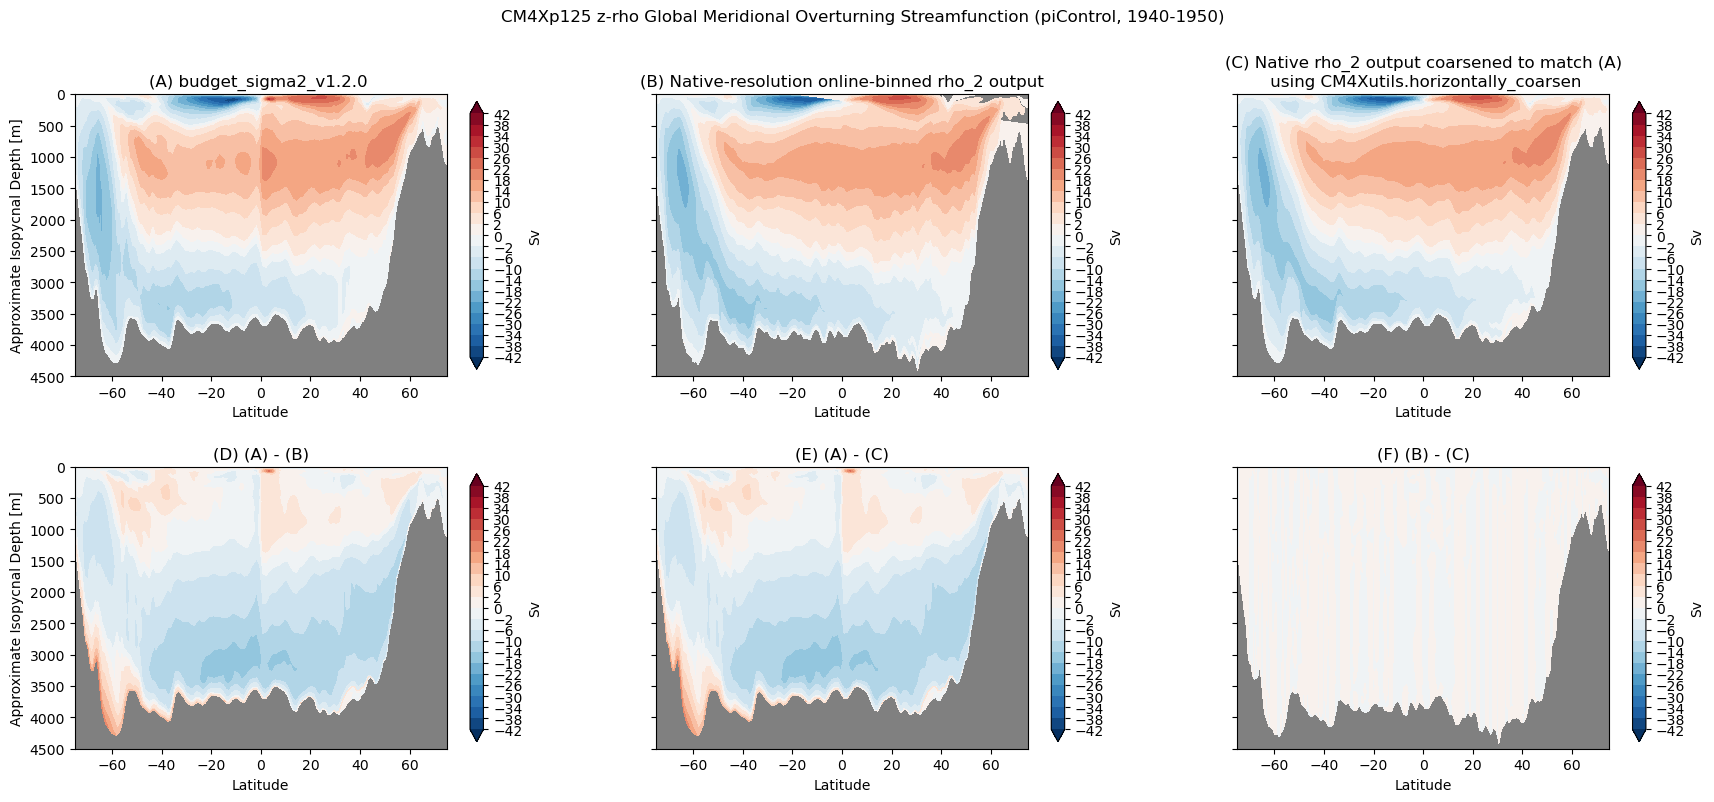

In [129]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(21, 8.5), sharey=True)

axA = axes[0, 0]
axB = axes[0, 1]
axC = axes[0, 2]
axD = axes[1, 0]
axE = axes[1, 1]
axF = axes[1, 2]

psi_hires_on_lat = 1 * psi_hires.swap_dims({"yq":"lat"})
psi_on_lat = 1 * psi.swap_dims({"yq":"lat"})
psi_hires_coarsened_on_lat = 1 * psi_coarsened_hires.swap_dims({"yq":"lat"})

psi_hires_on_lat = psi_hires_on_lat.interp(lat=psi_on_lat.lat.values)
psi_hires_on_lat.coords["sigma2_l"] = psi_hires["sigma2_l"].values - 1000
psi_hires_coarsened_on_lat.coords["sigma2_l"] = psi_hires["sigma2_l"].values - 1000
psi_hires_coarsened_on_lat["yq"].values = 1 * psi["yq"].values
psi_hires_coarsened_on_lat.coords["lat"] = 1 * psi["lat"].values

psi_on_lat = psi_on_lat.sel(sigma2_l=psi_hires_on_lat.coords["sigma2_l"].values)

exp = "control"

ax = axA
plot_psi(fig, ax, psi_on_lat.fillna(0.0).sel(exp=exp))
ax.set_title("(A) budget_sigma2_v1.2.0 ")

ax = axB
plot_psi(fig, ax, psi_hires_on_lat.fillna(0.0))
ax.set_ylabel("")
ax.set_title("(B) Native-resolution online-binned rho_2 output")

ax = axC
plot_psi(fig, ax, psi_hires_coarsened_on_lat.fillna(0.0))
ax.set_ylabel("")
ax.set_title("(C) Native rho_2 output coarsened to match (A)\n using CM4Xutils.horizontally_coarsen")

ax = axD
difference_ab = psi_on_lat.fillna(0.0).sel(exp=exp) - psi_hires_on_lat.fillna(0.0)
difference_ab.coords["depth"] = 1 * psi_on_lat.depth.fillna(0.0).sel(exp=exp)
plot_psi(fig, ax, difference_ab.fillna(0.0))
ax.set_title("(D) (A) - (B)")

ax = axE
difference_ac = psi_on_lat.fillna(0.0).sel(exp=exp) - psi_hires_coarsened_on_lat.fillna(0.0)
difference_ac.coords["depth"] = 1 * psi_on_lat.depth.fillna(0.0).sel(exp=exp)
plot_psi(fig, ax, difference_ac.fillna(0.0))
ax.set_ylabel("")
ax.set_title("(E) (A) - (C)")

ax = axF
difference_bc = psi_hires_on_lat.fillna(0.0) - psi_hires_coarsened_on_lat.fillna(0.0)
difference_bc.coords["depth"] = 1 * psi_hires_on_lat.depth.fillna(0.0)
plot_psi(fig, ax, difference_bc.fillna(0.0))
ax.set_ylabel("")
ax.set_title("(F) (B) - (C)")

[a.set_xlabel("Latitude") for a in axes.flatten()]
fig.suptitle("CM4Xp125 z-rho Global Meridional Overturning Streamfunction (piControl, 1940-1950)")
fig.subplots_adjust(wspace=0.25, hspace=0.32)
fig.savefig("streamfunction_comparison.png", dpi = 200, bbox_inches = "tight")

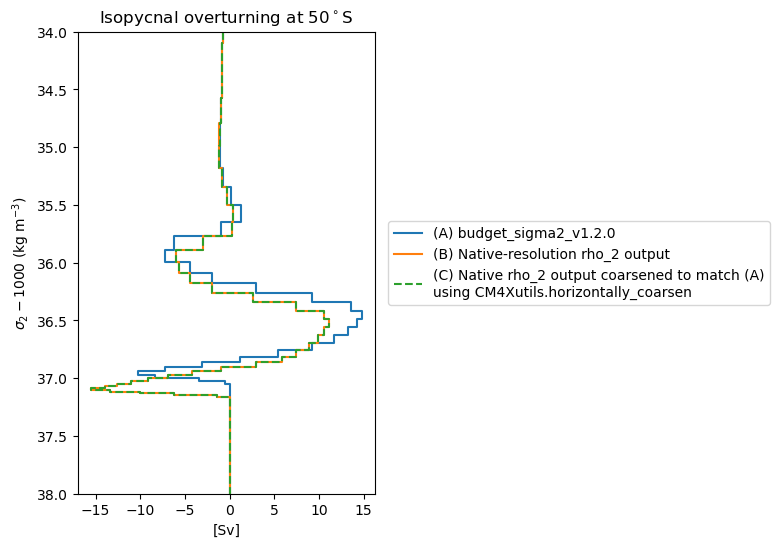

In [135]:
lat = -50
exp = "control"

A = psi_on_lat.interp(lat=lat).sel(exp=exp)
B = psi_hires_on_lat.interp(lat=lat)
C = psi_hires_coarsened_on_lat.interp(lat=lat)

fig, ax = plt.subplots(figsize=(5, 6))

ax.step(A, A.sigma2_l, where="mid", label="(A) budget_sigma2_v1.2.0")
ax.step(B, B.sigma2_l, where="mid", label="(B) Native-resolution rho_2 output")
ax.step(C, C.sigma2_l, where="mid", label="(C) Native rho_2 output coarsened to match (A)\nusing CM4Xutils.horizontally_coarsen", linestyle = "--")

ax.set_ylim(34, 38)

ax.invert_yaxis()
ax.set_xlabel("[Sv]")
ax.set_ylabel(r"$\sigma_2 - 1000$ (kg m$^{-3}$)")
ax.set_title(f"Isopycnal overturning at {np.abs(lat)}$^\\circ$S")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
fig.subplots_adjust(right=0.72)
fig.savefig("streamfunction_profile_comparison.png", dpi = 200, bbox_inches = "tight")

In [136]:
## fig, axes = plt.subplots(2, 3, figsize=(21, 8.5), sharey=True)

axA = axes[0, 0]
axB = axes[0, 1]
axC = axes[0, 2]
axD = axes[1, 0]
axE = axes[1, 1]
axF = axes[1, 2]

psi_hires_on_lat = 1 * psi_hires.swap_dims({"yq":"lat"})
psi_on_lat = 1 * psi.swap_dims({"yq":"lat"})
psi_hires_coarsened_on_lat = 1 * psi_coarsened_hires.swap_dims({"yq":"lat"})

psi_hires_on_lat = psi_hires_on_lat.interp(lat=psi_on_lat.lat.values)
psi_hires_on_lat.coords["sigma2_l"] = psi_hires["sigma2_l"].values - 1000
psi_hires_coarsened_on_lat.coords["sigma2_l"] = psi_hires["sigma2_l"].values - 1000
psi_hires_coarsened_on_lat["yq"].values = 1 * psi["yq"].values
psi_hires_coarsened_on_lat.coords["lat"] = 1 * psi["lat"].values

psi_on_lat = psi_on_lat.sel(sigma2_l=psi_hires_on_lat.coords["sigma2_l"].values)

exp = "control"

ax = axA
plot_psi_density(fig, ax, psi_on_lat.fillna(0.0).sel(exp=exp))
ax.set_title("(A) budget_sigma2_v1.2.0")

ax = axB
plot_psi_density(fig, ax, psi_hires_on_lat.fillna(0.0))
ax.set_ylabel("")
ax.set_title("(B) Native-resolution rho_2 output")

ax = axC
plot_psi_density(fig, ax, psi_hires_coarsened_on_lat.fillna(0.0))
ax.set_ylabel("")
ax.set_title("(C) Native rho_2 output coarsened to match (A)\nusing CM4Xutils.horizontally_coarsen")

ax = axD
difference_ab = psi_on_lat.fillna(0.0).sel(exp=exp) - psi_hires_on_lat.fillna(0.0)
plot_psi_density(fig, ax, difference_ab.fillna(0.0))
ax.set_title("(D) (A) - (B)")

ax = axE
difference_ac = psi_on_lat.fillna(0.0).sel(exp=exp) - psi_hires_coarsened_on_lat.fillna(0.0)
plot_psi_density(fig, ax, difference_ac.fillna(0.0))
ax.set_ylabel("")
ax.set_title("(E) (A) - (C)")

ax = axF
difference_bc = psi_hires_on_lat.fillna(0.0) - psi_hires_coarsened_on_lat.fillna(0.0)
plot_psi_density(fig, ax, difference_bc.fillna(0.0))
ax.set_ylabel("")
ax.set_title("(F) (B) - (C)")

[a.set_xlabel("Latitude") for a in axes.flatten()]
fig.suptitle("Isopycnal Global Meridional Overturning Streamfunction (piControl, 1940-1950)")
fig.subplots_adjust(wspace=0.25, hspace=0.32)